# Yellow taxi Project Goal :
* Build a random forest classifier to predict which cutomers would be ( Classified ) as 'generous tipper' ( >=20% ).
* Create an executive summary for the stakeholders


## Exploratory Data Analysis & Data Cleaning

In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBClassifier, XGBRegressor

In [2]:
df= pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')
df.head(10)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36
6,37660487,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,N,79,241,1,47.5,1.0,0.5,9.86,0.0,0.3,59.16
7,69059411,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,N,237,114,1,16.0,1.0,0.5,1.78,0.0,0.3,19.58
8,8433159,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,N,234,249,2,9.0,0.0,0.5,0.00,0.0,0.3,9.80
9,95294817,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,N,239,237,1,13.0,0.0,0.5,2.75,0.0,0.3,16.55


In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

(22699, 18)

In [4]:
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


#### Now we will eliminate unnecessary features/columns - Lots of feature cause overfitting.The columns will be removed at phase 1
* Unnamed
* VendorID
* extra
* mta_tax
* tolls_amount
* improovement_surcharge
* store_and_fwd_flag
* PULocationID
* DOLocationID


In [5]:
df1 = df.drop(['Unnamed: 0', 'mta_tax', 'store_and_fwd_flag','DOLocationID', 'PULocationID'], axis=1)


In [6]:
df1.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,1,13.0,0.0,2.76,0.0,0.3,16.56
1,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,1,16.0,0.0,4.00,0.0,0.3,20.80
2,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,1,6.5,0.0,1.45,0.0,0.3,8.75
3,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,1,20.5,0.0,6.39,0.0,0.3,27.69
4,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,2,16.5,0.5,0.00,0.0,0.3,17.80
5,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,1,9.0,0.5,2.06,0.0,0.3,12.36
6,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,1,47.5,1.0,9.86,0.0,0.3,59.16
7,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,1,16.0,1.0,1.78,0.0,0.3,19.58
8,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,2,9.0,0.0,0.00,0.0,0.3,9.80
9,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,1,13.0,0.0,2.75,0.0,0.3,16.55


In [7]:
#calculating trip duration in minutes from the start and end time columns
df1['trip_duration']=(pd.to_datetime(df1['tpep_dropoff_datetime'])-pd.to_datetime(df1['tpep_pickup_datetime'])).dt.total_seconds()/60
df1['trip_duration']= df1['trip_duration'].round(2)
df1.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration
0,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,1,13.0,0.0,2.76,0.0,0.3,16.56,14.07
1,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,1,16.0,0.0,4.00,0.0,0.3,20.80,26.50
2,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,1,6.5,0.0,1.45,0.0,0.3,8.75,7.20
3,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,1,20.5,0.0,6.39,0.0,0.3,27.69,30.25
4,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,2,16.5,0.5,0.00,0.0,0.3,17.80,16.72
5,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,1,9.0,0.5,2.06,0.0,0.3,12.36,8.00
6,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,1,47.5,1.0,9.86,0.0,0.3,59.16,59.63
7,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,1,16.0,1.0,1.78,0.0,0.3,19.58,21.98
8,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,2,9.0,0.0,0.00,0.0,0.3,9.80,12.12
9,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,1,13.0,0.0,2.75,0.0,0.3,16.55,20.43


In [8]:
# now that we have trip duration we can drop the pickup and drop datetime columns
df2 = df1.drop(['tpep_pickup_datetime', 'tpep_dropoff_datetime'], axis=1)
df2.head()

,VendorID,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration
0,2,6,3.34,1,1,13.0,0.0,2.76,0.0,0.3,16.56,14.07
1,1,1,1.80,1,1,16.0,0.0,4.00,0.0,0.3,20.80,26.50
2,1,1,1.00,1,1,6.5,0.0,1.45,0.0,0.3,8.75,7.20
3,2,1,3.70,1,1,20.5,0.0,6.39,0.0,0.3,27.69,30.25
4,2,1,4.37,1,2,16.5,0.5,0.00,0.0,0.3,17.80,16.72


In [9]:
#selected potential features to examine statistical data.
df2[['trip_distance', 'fare_amount', 'total_amount', 'trip_duration']].describe()

,trip_distance,fare_amount,total_amount,trip_duration
count,22699.000000,22699.000000,22699.000000,22699.000000
mean,2.913313,13.026629,16.310502,17.013766
std,3.653171,13.243791,16.097295,61.996476
min,0.000000,-120.000000,-120.300000,-16.980000
25%,0.990000,6.500000,8.750000,6.650000
50%,1.610000,9.500000,11.800000,11.180000
75%,3.060000,14.500000,17.800000,18.380000
max,33.960000,999.990000,1200.290000,1439.550000


#### Anomaly found - 
* Negative fare & Total amount amount
* Very very high fare & total amount - can be concluded unrealistic
* Negative trip duration
* Maximum trip duration - Max trip duration showing 1439 mins , close to 24 hours- Can be conluded as global outlier

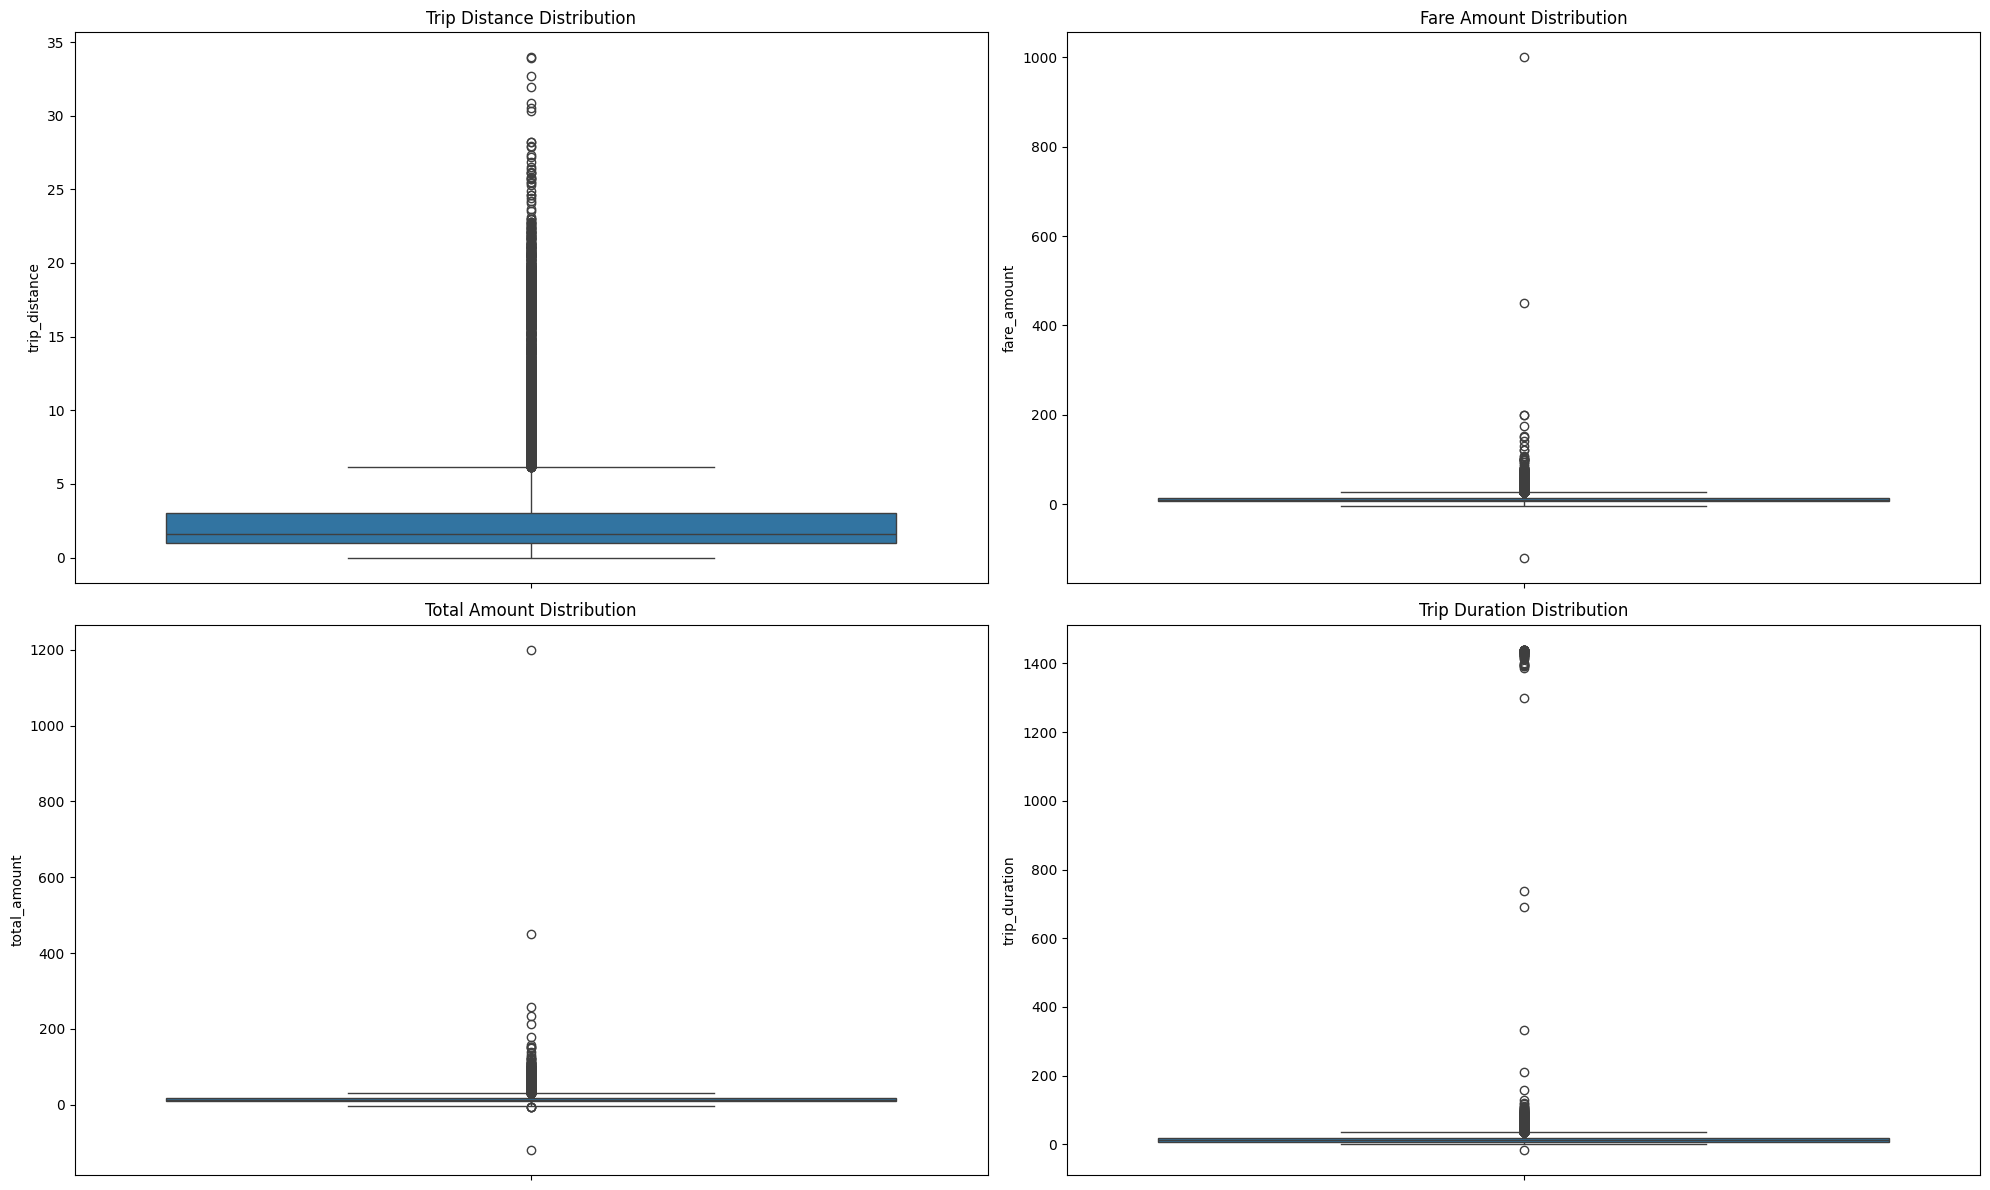

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Create individual boxplots
features = ['trip_distance', 'fare_amount', 'total_amount', 'trip_duration']
sns.boxplot(data=df2, y='trip_distance', ax=axes[0,0])
sns.boxplot(data=df2, y='fare_amount', ax=axes[0,1])
sns.boxplot(data=df2, y='total_amount', ax=axes[1,0])
sns.boxplot(data=df2, y='trip_duration', ax=axes[1,1])

# Set titles for each subplot
axes[0,0].set_title('Trip Distance Distribution')
axes[0,1].set_title('Fare Amount Distribution')
axes[1,0].set_title('Total Amount Distribution')
axes[1,1].set_title('Trip Duration Distribution')

plt.tight_layout()
plt.show()


In [11]:
#trip duration and trip_distance, fare_amount, 'total_amount' seems to have the most global outliers, but removing then can cause significant reduction in observation.
# like, the total number of original observation which is 22000+ , will be reduced to 1600+ observations.
# herefore removing the negatives and global outliers only/
'''
q3= df2[['trip_duration', 'trip_distance','fare_amount', 'total_amount']].quantile(0.75)
q1= df2[['trip_duration', 'trip_distance','fare_amount', 'total_amount']].quantile(0.25)
iqr= q3-q1
upperlim= q3+(1.5*iqr)
lowerlim= q1-(1.5*iqr)

df3= df2[(df2['trip_duration']<=upperlim['trip_duration'])&
         (df2['trip_distance']<=upperlim['trip_distance'])&
         (df2['trip_duration']>=lowerlim['trip_duration'])&
         (df2['trip_distance']>=lowerlim['trip_distance'])&
         (df2['fare_amount']<=upperlim['trip_duration'])&
         (df2['total_amount']<=upperlim['trip_distance'])&
         (df2['fare_amount']>=lowerlim['trip_duration'])&
         (df2['total_amount']>=lowerlim['trip_distance'])]

df3.head()
'''
df2.shape


(22699, 12)

In [12]:
#chcking if we still have negative values
df2.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration
count,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,1.556236,1.642319,2.913313,1.043394,1.336887,13.026629,0.333275,1.835781,0.312542,0.299551,16.310502,17.013766
std,0.496838,1.285231,3.653171,0.708391,0.496211,13.243791,0.463097,2.800626,1.399212,0.015673,16.097295,61.996476
min,1.000000,0.000000,0.000000,1.000000,1.000000,-120.000000,-1.000000,0.000000,0.000000,-0.300000,-120.300000,-16.980000
25%,1.000000,1.000000,0.990000,1.000000,1.000000,6.500000,0.000000,0.000000,0.000000,0.300000,8.750000,6.650000
50%,2.000000,1.000000,1.610000,1.000000,1.000000,9.500000,0.000000,1.350000,0.000000,0.300000,11.800000,11.180000
75%,2.000000,2.000000,3.060000,1.000000,2.000000,14.500000,0.500000,2.450000,0.000000,0.300000,17.800000,18.380000
max,2.000000,6.000000,33.960000,99.000000,4.000000,999.990000,4.500000,200.000000,19.100000,0.300000,1200.290000,1439.550000


In [13]:
#removing negative rows
# ...existing code...
cols = ['fare_amount', 'total_amount', 'extra', 'improvement_surcharge', 'trip_duration']

# drop rows where ANY of the listed cols <= 0
# any(axis=1) is to identify which rows match the specified condition across columns.

df2_filtered = df2[(df2[cols]>=0).all(axis=1)]
df2_filtered.shape

(22684, 12)

<Axes: ylabel='tip_amount'>

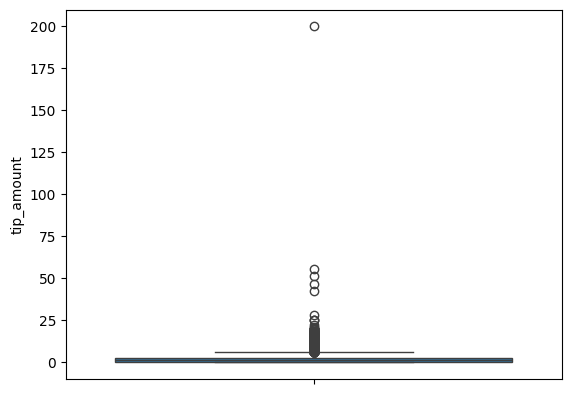

In [14]:
#checking quartile wise distribution.
sns.boxplot(data=df2_filtered, y='tip_amount')

## Feature Engineering -
Now that we have cleaned the data and eliminated the negatives and global outliers, we can focus on engineering different features.
With current dataset , we can construct the following features -

#### tip_category : From the boxplot and statistics we can conclude that the tip_amount is concentrated between 0$ to 10$, with a mean of 1.8$. therefore we can divide the tip_Category in three part - 
* Regular  (0-2$) -> 1, 
* generous (2 to 5$) -> 2, 
* Kind Hearted (5$ and above ) -> 3.

**remember , the tip_category feature's values must be in numerical form.**


In [15]:
#defining a function for 
def tip_cat(amount):
    if amount< 2:
        return(1)
    elif amount >=2 and amount < 5:
        return(2)
    else :
        return(3)
         

df2_filtered['tip_category']=df2_filtered['tip_amount'].apply(tip_cat)
df2_filtered.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_7256\743383891.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_filtered['tip_category']=df2_filtered['tip_amount'].apply(tip_cat)


,VendorID,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration,tip_category
0,2,6,3.34,1,1,13.0,0.0,2.76,0.0,0.3,16.56,14.07,2
1,1,1,1.80,1,1,16.0,0.0,4.00,0.0,0.3,20.80,26.50,2
2,1,1,1.00,1,1,6.5,0.0,1.45,0.0,0.3,8.75,7.20,1
3,2,1,3.70,1,1,20.5,0.0,6.39,0.0,0.3,27.69,30.25,3
4,2,1,4.37,1,2,16.5,0.5,0.00,0.0,0.3,17.80,16.72,1


In [16]:
#now we will set two dataframe - A) for predicting fare_amount , B) for classifying tip_category
df_fare_amount= df2_filtered.drop('tip_category', axis=1)
df_tip_cat= df2_filtered


In [17]:
df2_filtered.groupby(['tip_category'])['tip_category'].count()

tip_category
1    14648
2     6276
3     1760
Name: tip_category, dtype: int64

## Model Construction & Selection - 

Now that we are done with data cleaning and feature engineering we will be proceeding with the MODEL Construction. Before we zero in on a spacific model,  We need to understand that, considering all these features and the complex non-linear relationship with the predicted variable (Y) and predictor variables (X) -here we don't want oberfitting, so we will ne using -

* randomforest classifier



### randomforest classifier -
This will be used to classify and identify 'generous' tipper

In [18]:
#test and train split
x= df_tip_cat.drop('tip_category', axis=1)
y= df_tip_cat['tip_category']

X_train, X_test, y_train, y_test= train_test_split(x, y, test_size=0.3, random_state=42)


In [19]:
rf= RandomForestClassifier(random_state=42)

params = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 4, 6,8],
    'n_estimators': [100, 200, 300, 400],
    'max_features': ['log2', 'sqrt'],
    'max_samples': [0.25, 0.5, 0.75 ,None]
}


''' now here we have to note that we are trying to perform multiclass classification, means we are classifying the tip into 3 categories.
therefore, while using scoring metrics like recall, f1, precision we have to make sure that we are using the average parameter as 'macro' or 
'weighted' to get proper results. what this average parameter does is it returns the mean of the metric calculated for each class.'''

# accuarcy does not require average parameter as it is by default calculated for multiclass classification.
score= ['accuracy', 'recall_weighted', 'f1_weighted', 'precision_weighted']


grid_cv= GridSearchCV(estimator= rf, param_grid= params, scoring= score, cv=4, refit='f1_weighted')

In [20]:
%%time
grid_cv.fit(X_train, y_train)

CPU times: total: 38min 15s
Wall time: 38min 39s


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 15, 20],
                         'max_features': ['log2', 'sqrt'],
                         'max_samples': [0.25, 0.5, 0.75, None],
                         'min_samples_split': [2, 4, 6, 8],
                         'n_estimators': [100, 200, 300, 400]},
             refit='f1_weighted',
             scoring=['accuracy', 'recall_weighted', 'f1_weighted',
                      'precision_weighted'])

In [21]:
grid_cv.best_params_

{'max_depth': 10,
 'max_features': 'log2',
 'max_samples': 0.5,
 'min_samples_split': 2,
 'n_estimators': 400}

In [22]:
rf_final= RandomForestClassifier(max_depth= 10, max_features= 'log2', max_samples= 0.5, min_samples_split= 2, n_estimators= 400, random_state=42)
rf_final.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features='log2', max_samples=0.5,
                       n_estimators=400, random_state=42)

In [23]:
from sklearn.metrics import precision_score


y_pred= rf_final.predict(X_test)
recall_score_weighted= recall_score(y_test, y_pred, average='weighted')
f1_score_weighted= f1_score(y_test, y_pred, average='weighted')
precision_score_weighted= precision_score(y_test, y_pred, average='weighted')
accuracy_1= accuracy_score(y_test, y_pred)


scores=pd.DataFrame({'Metrics': ['Accuracy', 'Recall_weighted', 'F1_weighted', 'Precision_weighted'],
              'Score': [accuracy_1, recall_score_weighted, f1_score_weighted, precision_score_weighted]})

scores

,Metrics,Score
0,Accuracy,0.999853
1,Recall_weighted,0.999853
2,F1_weighted,0.999853
3,Precision_weighted,0.999853


### Observation : 
from the previous scores, as we can see that the scores are pretty good. Yes it is possible or very very much possible case of overfitting, BUT we are gonna go with this, as it is for test purpose. 

But as a show of work here is a full merged dataframe show casing the actual Y values and predicted/classified Y values 


In [24]:
#reset_index() -> reset_the old index of y_test to align with X_test and form a new column with new indexing
#drop=true -> to avoid adding the old index as a new column
predicted_set= pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)
predicted_set['Predicted_tip_category']= y_pred

#final show of work 
# dataset showcasing predicted vs actual value - tip_category vs predicted_tip_category

predicted_set[4:].tail(10)



,VendorID,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration,tip_category,Predicted_tip_category
6796,1,1,2.40,1,2,10.5,0.5,0.00,0.0,0.3,11.80,12.13,1,1
6797,2,1,3.19,1,1,16.0,0.0,5.04,0.0,0.3,21.84,21.28,3,3
6798,1,2,6.90,1,1,21.0,1.0,4.00,0.0,0.3,26.80,17.23,2,2
6799,1,1,5.90,1,1,20.5,0.5,2.00,0.0,0.3,23.80,20.55,2,2
6800,2,3,1.51,1,2,11.0,0.0,0.00,0.0,0.3,11.80,16.38,1,1
6801,1,1,11.10,1,1,36.0,0.0,7.35,0.0,0.3,44.15,44.22,3,3
6802,1,2,14.60,1,1,42.0,0.0,0.00,0.0,0.3,42.80,34.58,1,1
6803,1,1,1.40,1,1,10.0,0.0,2.15,0.0,0.3,12.95,13.83,2,2
6804,2,6,1.75,1,1,10.0,0.0,1.00,0.0,0.3,11.80,12.90,1,1
6805,2,1,2.27,1,1,14.0,0.0,2.96,0.0,0.3,17.76,19.93,2,2
